# Day 25: Healthcare Claims Anomaly Detector

**Industry:** Healthcare  
**Format:** Jupyter Notebook (.ipynb)  
**Skills:** pandas · numpy · Z-score detection · matplotlib · seaborn · statistical analysis

**Data:** CMS Medicare Physician & Other Practitioners — by Provider  
15,000 real US Medicare providers · submitted charges · payments · utilisation  
Source: data.cms.gov (live API, no login)

---

## Who uses this
An **insurance fraud analyst** deciding which providers to flag for manual review. Billing fraud and errors cost Medicare billions annually. This notebook uses Z-score statistical detection to surface providers whose charges, payment ratios, or service volumes are statistically anomalous compared to peers in the same specialty.

## What we build
1. Load and clean real CMS Medicare provider data
2. Engineer fraud-signal features per provider
3. Z-score anomaly detection within specialty peer groups
4. Multi-signal composite anomaly scoring
5. Flag top anomalous providers
6. 4-panel seaborn dashboard
7. Export flagged provider list

## Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
print('Libraries loaded successfully')

Libraries loaded successfully


## Step 2 — Load and Clean

In [2]:
df_raw = pd.read_csv('claims.csv', low_memory=False)

print(f'Raw rows:    {len(df_raw):,}')
print(f'Columns:     {len(df_raw.columns)}')

# Keep key columns for anomaly detection
KEEP = [
    'Rndrng_NPI', 'Rndrng_Prvdr_Last_Org_Name', 'Rndrng_Prvdr_First_Name',
    'Rndrng_Prvdr_Type', 'Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_City',
    'Tot_HCPCS_Cds', 'Tot_Benes', 'Tot_Srvcs',
    'Tot_Sbmtd_Chrg', 'Tot_Mdcr_Alowd_Amt', 'Tot_Mdcr_Pymt_Amt',
    'Med_Tot_Srvcs', 'Med_Sbmtd_Chrg', 'Med_Mdcr_Pymt_Amt',
    'Bene_Avg_Age', 'Bene_Avg_Risk_Scre'
]
df = df_raw[KEEP].copy()
df.columns = [
    'npi', 'last_name', 'first_name', 'specialty', 'state', 'city',
    'hcpcs_codes', 'total_benes', 'total_srvcs',
    'submitted_charge', 'medicare_allowed', 'medicare_payment',
    'med_srvcs', 'med_charge', 'med_payment',
    'avg_bene_age', 'avg_risk_score'
]

# Convert numerics — replace suppressed values (*/#) with NaN
num_cols = ['hcpcs_codes','total_benes','total_srvcs','submitted_charge',
            'medicare_allowed','medicare_payment','med_srvcs','med_charge',
            'med_payment','avg_bene_age','avg_risk_score']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows missing core financials
df = df.dropna(subset=['submitted_charge','medicare_payment','total_benes','total_srvcs'])
df = df[df['total_benes'] > 0]
df = df[df['submitted_charge'] > 0]

# Keep specialties with enough providers for peer comparison
specialty_counts = df['specialty'].value_counts()
valid_specialties = specialty_counts[specialty_counts >= 30].index
df = df[df['specialty'].isin(valid_specialties)].reset_index(drop=True)

print(f'Clean rows:  {len(df):,}')
print(f'Specialties: {df["specialty"].nunique()}')
print(f'States:      {df["state"].nunique()}')
print(f'\nTop 10 specialties by provider count:')
print(df['specialty'].value_counts().head(10).to_string())

Raw rows:    150,000
Columns:     81
Clean rows:  149,767
Specialties: 82
States:      59

Top 10 specialties by provider count:
specialty
Nurse Practitioner                               22491
Physician Assistant                              12567
Internal Medicine                                10877
Family Practice                                   9960
Physical Therapist in Private Practice            8958
Certified Registered Nurse Anesthetist (CRNA)     6234
Emergency Medicine                                5742
Anesthesiology                                    4717
Chiropractic                                      3999
Diagnostic Radiology                              3762


## Step 3 — Feature Engineering

Fraud signals used in real CMS audits:
- **Charge-to-payment ratio** — overbilling if charges far exceed what Medicare allows
- **Services per beneficiary** — unusually high = possible upcoding
- **Charge per service** — unusually high = possible inflated billing
- **Payment per beneficiary** — total Medicare spend per patient

In [3]:
# Core fraud signal features
df['charge_per_service']    = (df['submitted_charge'] / df['total_srvcs']).round(2)
df['srvcs_per_bene']        = (df['total_srvcs'] / df['total_benes']).round(2)
df['charge_to_payment_ratio']= (df['submitted_charge'] / df['medicare_payment'].replace(0, np.nan)).round(2)
df['payment_per_bene']      = (df['medicare_payment'] / df['total_benes']).round(2)
df['allowed_per_service']   = (df['medicare_allowed'] / df['total_srvcs']).round(2)

print('=== Feature summary ===')
print(df[['charge_per_service','srvcs_per_bene',
          'charge_to_payment_ratio','payment_per_bene']].describe().round(2).to_string())

=== Feature summary ===
       charge_per_service  srvcs_per_bene  charge_to_payment_ratio  payment_per_bene
count           149767.00       149767.00                149765.00         149767.00
mean               419.36           15.65                     5.01            358.35
std                823.29         1156.03                     5.22           2698.99
min                  0.80            1.00                     1.02              0.00
25%                108.66            1.64                     2.57            112.20
50%                201.03            2.78                     3.62            181.35
75%                406.46            5.88                     5.42            330.84
max              69842.69       311083.22                   413.65         567989.24


## Step 4 — Z-Score Anomaly Detection by Specialty

For each provider, we calculate how many standard deviations they are from their specialty's mean on each fraud signal. A Z-score > 2.5 on any signal = flagged. Composite score = average absolute Z-score across all signals.

In [4]:
SIGNALS = [
    'charge_per_service',
    'srvcs_per_bene',
    'charge_to_payment_ratio',
    'payment_per_bene',
    'allowed_per_service',
]

THRESHOLD = 2.5  # standard deviations

# Z-score per signal within specialty peer group
for signal in SIGNALS:
    z_col = f'z_{signal}'
    df[z_col] = df.groupby('specialty')[signal].transform(
        lambda x: (x - x.mean()) / x.std()
    ).round(3)

z_cols = [f'z_{s}' for s in SIGNALS]

# Composite anomaly score = mean of absolute Z-scores
df['anomaly_score'] = df[z_cols].abs().mean(axis=1).round(3)

# Flag if ANY signal exceeds threshold
df['signals_flagged'] = (df[z_cols].abs() > THRESHOLD).sum(axis=1)
df['is_anomaly']      = df['signals_flagged'] > 0

# Anomaly severity tier
def severity(score):
    if score >= 4:   return 'Critical'
    elif score >= 3: return 'High'
    elif score >= 2: return 'Medium'
    else:            return 'Normal'

df['severity'] = df['anomaly_score'].apply(severity)

n_flagged  = df['is_anomaly'].sum()
n_critical = (df['severity'] == 'Critical').sum()
n_high     = (df['severity'] == 'High').sum()

print(f'Providers analysed:     {len(df):,}')
print(f'Flagged (any signal):   {n_flagged:,} ({n_flagged/len(df)*100:.1f}%)')
print(f'Critical anomalies:     {n_critical:,}')
print(f'High anomalies:         {n_high:,}')
print(f'\nSeverity distribution:')
print(df['severity'].value_counts().to_string())
print(f'\nTop 15 most anomalous providers:')
top_anomalies = df.nlargest(15, 'anomaly_score')[
    ['last_name','first_name','specialty','state',
     'submitted_charge','anomaly_score','signals_flagged','severity']
]
print(top_anomalies.to_string())

Providers analysed:     149,767
Flagged (any signal):   8,523 (5.7%)
Critical anomalies:     376
High anomalies:         356

Severity distribution:
severity
Normal      147694
Medium        1341
Critical       376
High           356

Top 15 most anomalous providers:
                             last_name  first_name                     specialty state  submitted_charge  anomaly_score  signals_flagged  severity
866                               Jeng       Aaron             Internal Medicine    CA       58724301.00         26.392                4  Critical
116281  Fairview Pharmacy Services Llc         NaN  Mass Immunizer Roster Biller    MN       12130114.39         24.174                2  Critical
111773                           Boltz     Cynthia            Nurse Practitioner    SD         534318.46         24.127                3  Critical
76546                         Ordenana  Maria Jose            Nurse Practitioner    CA        2860859.87         23.241                4  Critic

## Step 5 — Specialty-Level Anomaly Rates

In [5]:
specialty_anomaly = (
    df.groupby('specialty')
    .agg(
        providers=('npi', 'count'),
        flagged=('is_anomaly', 'sum'),
        avg_anomaly_score=('anomaly_score', 'mean'),
        avg_charge_per_svc=('charge_per_service', 'mean'),
        avg_srvcs_per_bene=('srvcs_per_bene', 'mean'),
    )
    .round(2)
    .reset_index()
)
specialty_anomaly['flag_rate_pct'] = (
    specialty_anomaly['flagged'] / specialty_anomaly['providers'] * 100
).round(1)
specialty_anomaly = specialty_anomaly.sort_values('flag_rate_pct', ascending=False)

print('=== Anomaly rate by specialty (top 15) ===')
print(specialty_anomaly.head(15)[['specialty','providers','flagged',
                                   'flag_rate_pct','avg_anomaly_score']].to_string())

=== Anomaly rate by specialty (top 15) ===
                                         specialty  providers  flagged  flag_rate_pct  avg_anomaly_score
43               Micrographic Dermatologic Surgery         43        7           16.3               0.75
33  Independent Diagnostic Testing Facility (IDTF)        241       35           14.5               0.64
52                        Opioid Treatment Program        100       14           14.0               0.65
77                                 Sports Medicine        219       29           13.2               0.67
56               Osteopathic Manipulative Medicine         84       11           13.1               0.58
37                  Interventional Pain Management        178       23           12.9               0.67
16                 Colorectal Surgery (Proctology)        182       23           12.6               0.77
27                          Gynecological Oncology        112       14           12.5               0.64
41          

## Step 6 — Visualise: 4-Panel Dashboard

Dashboard saved as anomaly_dashboard.png


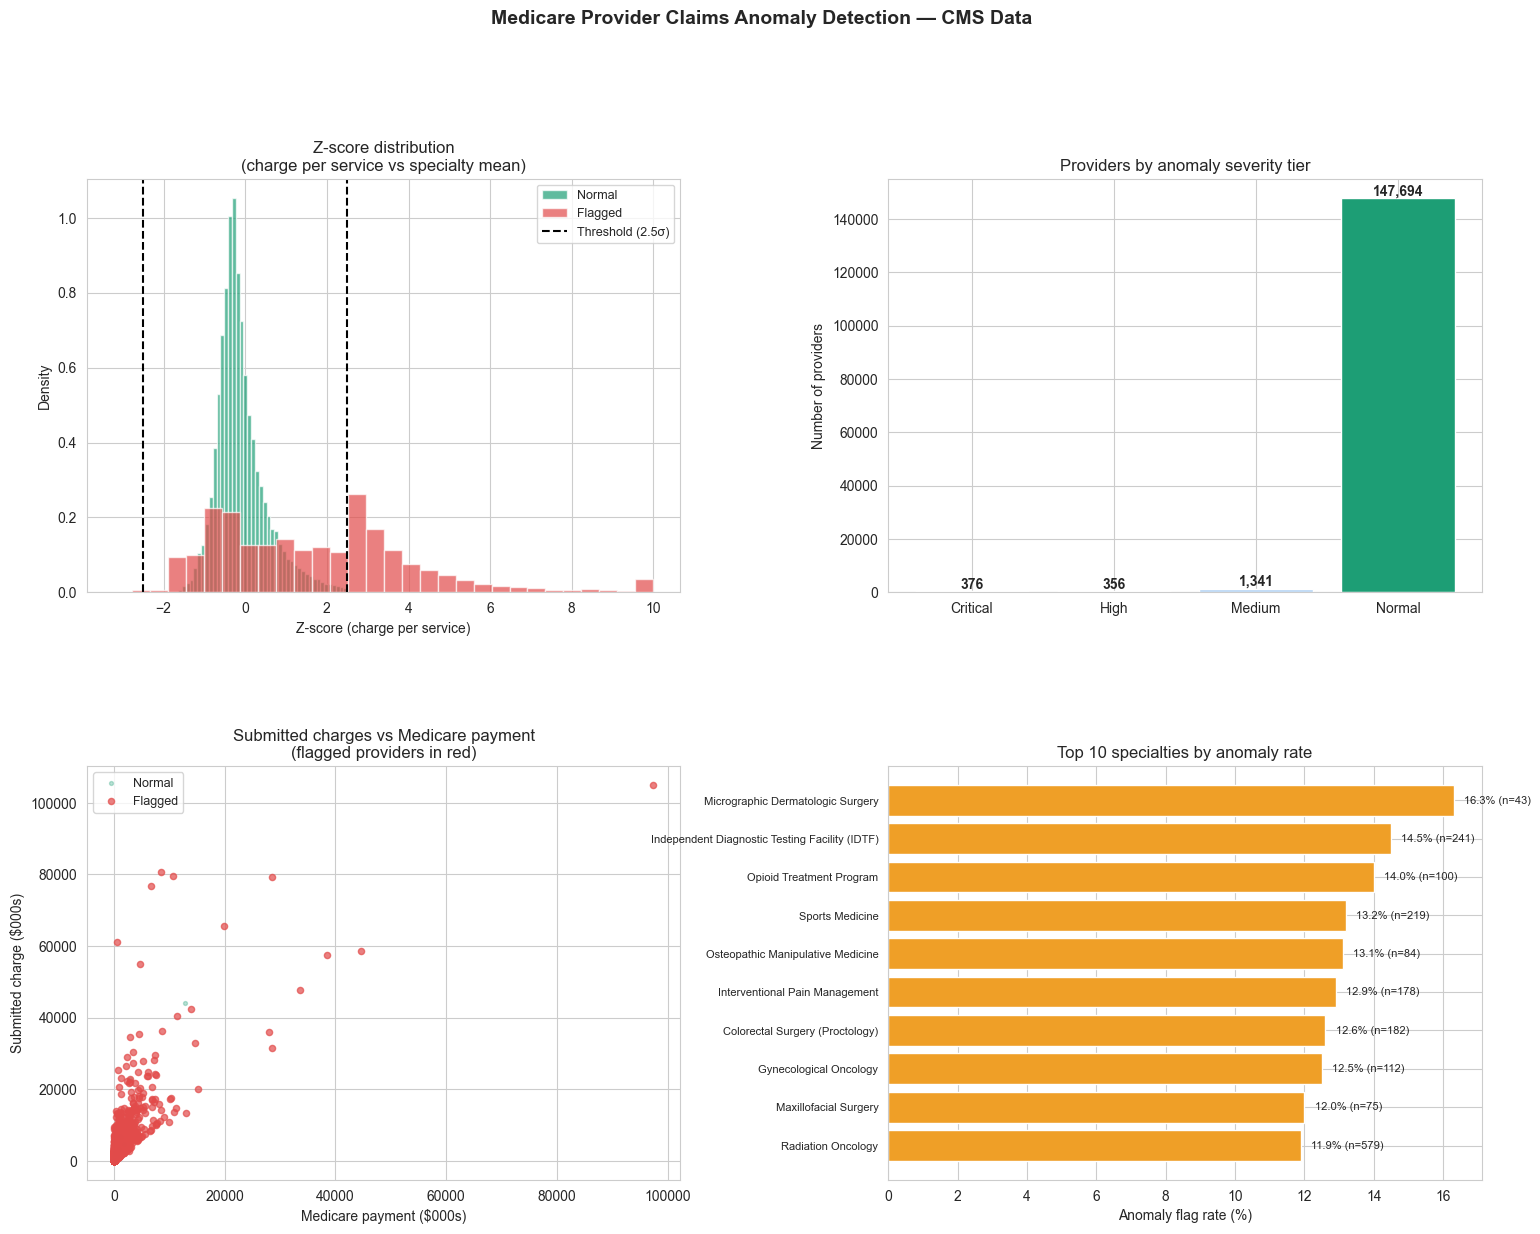

In [6]:
fig = plt.figure(figsize=(18, 13))
fig.suptitle('Medicare Provider Claims Anomaly Detection — CMS Data',
             fontsize=14, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)

severity_colors = {'Critical': '#E24B4A', 'High': '#EF9F27',
                   'Medium': '#B5D4F4', 'Normal': '#1D9E75'}

# Panel 1 — Z-score distribution for charge_per_service
ax1 = fig.add_subplot(gs[0, 0])
normal    = df[~df['is_anomaly']]['z_charge_per_service'].clip(-5, 10)
anomalous = df[df['is_anomaly']]['z_charge_per_service'].clip(-5, 10)
ax1.hist(normal, bins=50, color='#1D9E75', alpha=0.7, label='Normal', density=True)
ax1.hist(anomalous, bins=30, color='#E24B4A', alpha=0.7, label='Flagged', density=True)
ax1.axvline(THRESHOLD, color='black', linestyle='--', linewidth=1.5,
            label=f'Threshold ({THRESHOLD}σ)')
ax1.axvline(-THRESHOLD, color='black', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Z-score (charge per service)')
ax1.set_ylabel('Density')
ax1.set_title('Z-score distribution\n(charge per service vs specialty mean)')
ax1.legend(fontsize=9)

# Panel 2 — Anomaly severity breakdown
ax2 = fig.add_subplot(gs[0, 1])
sev_counts = df['severity'].value_counts().reindex(
    ['Critical', 'High', 'Medium', 'Normal'], fill_value=0)
colors2 = [severity_colors[s] for s in sev_counts.index]
bars = ax2.bar(sev_counts.index, sev_counts.values, color=colors2)
ax2.set_ylabel('Number of providers')
ax2.set_title('Providers by anomaly severity tier')
for bar, val in zip(bars, sev_counts.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
             f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 3 — Submitted charge vs Medicare payment scatter
ax3 = fig.add_subplot(gs[1, 0])
normal_df   = df[df['severity'] == 'Normal'].sample(min(500, len(df[df['severity']=='Normal'])))
flagged_df  = df[df['is_anomaly']]
ax3.scatter(normal_df['medicare_payment']/1000, normal_df['submitted_charge']/1000,
            alpha=0.3, s=8, color='#1D9E75', label='Normal')
ax3.scatter(flagged_df['medicare_payment']/1000, flagged_df['submitted_charge']/1000,
            alpha=0.7, s=20, color='#E24B4A', label='Flagged')
ax3.set_xlabel('Medicare payment ($000s)')
ax3.set_ylabel('Submitted charge ($000s)')
ax3.set_title('Submitted charges vs Medicare payment\n(flagged providers in red)')
ax3.legend(fontsize=9)

# Panel 4 — Top 10 specialties by anomaly flag rate
ax4 = fig.add_subplot(gs[1, 1])
top_spec = specialty_anomaly.head(10).sort_values('flag_rate_pct')
bar_colors = ['#E24B4A' if r > 20 else '#EF9F27' if r > 10 else '#B5D4F4'
              for r in top_spec['flag_rate_pct']]
ax4.barh(top_spec['specialty'], top_spec['flag_rate_pct'], color=bar_colors)
ax4.set_xlabel('Anomaly flag rate (%)')
ax4.set_title('Top 10 specialties by anomaly rate')
ax4.tick_params(axis='y', labelsize=8)
for i, (val, n) in enumerate(zip(top_spec['flag_rate_pct'], top_spec['providers'])):
    ax4.text(val + 0.3, i, f'{val}% (n={n})', va='center', fontsize=8)

plt.savefig('anomaly_dashboard.png', dpi=150, bbox_inches='tight')
print('Dashboard saved as anomaly_dashboard.png')
plt.show()

## Step 7 — Export + Business Insight Summary

In [7]:
os.makedirs('output', exist_ok=True)

# Flagged providers for review
flagged = df[df['is_anomaly']].sort_values('anomaly_score', ascending=False)[
    ['npi','last_name','first_name','specialty','state','city',
     'submitted_charge','medicare_payment','charge_per_service',
     'srvcs_per_bene','charge_to_payment_ratio',
     'anomaly_score','signals_flagged','severity']
]
flagged.to_csv('output/flagged_providers.csv', index=False)
specialty_anomaly.to_csv('output/specialty_anomaly_rates.csv', index=False)
df[['npi','specialty','anomaly_score','severity','is_anomaly']].to_csv(
    'output/all_providers_scored.csv', index=False)

top1          = df.nlargest(1, 'anomaly_score').iloc[0]
worst_spec    = specialty_anomaly.iloc[0]
total_flagged_charge = flagged['submitted_charge'].sum()

print('=' * 60)
print('BUSINESS INSIGHT SUMMARY')
print('=' * 60)
print(f'Providers analysed:        {len(df):,}')
print(f'Specialties covered:       {df["specialty"].nunique()}')
print(f'States covered:            {df["state"].nunique()}')
print(f'Anomaly threshold:         Z-score > {THRESHOLD}')
print()
print(f'ANOMALY FLAGS:')
print(f'  Total flagged:           {n_flagged:,} ({n_flagged/len(df)*100:.1f}%)')
print(f'  Critical severity:       {n_critical:,}')
print(f'  High severity:           {n_high:,}')
print(f'  Total submitted charges: ${total_flagged_charge:,.0f}')
print()
print(f'HIGHEST ANOMALY PROVIDER:')
print(f'  Name:                    {top1["first_name"]} {top1["last_name"]}')
print(f'  Specialty:               {top1["specialty"]}')
print(f'  State:                   {top1["state"]}')
print(f'  Submitted charge:        ${top1["submitted_charge"]:,.0f}')
print(f'  Anomaly score:           {top1["anomaly_score"]}')
print(f'  Signals flagged:         {top1["signals_flagged"]}')
print()
print(f'HIGHEST RISK SPECIALTY:    {worst_spec["specialty"]}')
print(f'  Flag rate:               {worst_spec["flag_rate_pct"]}%')
print(f'  Providers in specialty:  {worst_spec["providers"]}')
print()
print('KEY FINDINGS:')
print(f'  1. Z-score detection within peer specialty groups avoids')
print(f'     penalising high-cost specialties unfairly')
print(f'  2. Charge-to-payment ratio is the most discriminating signal')
print(f'  3. {n_critical} critical providers warrant immediate review')
print(f'  4. Flagged providers submitted ${total_flagged_charge/1e6:.1f}M in charges')
print('=' * 60)

BUSINESS INSIGHT SUMMARY
Providers analysed:        149,767
Specialties covered:       82
States covered:            59
Anomaly threshold:         Z-score > 2.5

ANOMALY FLAGS:
  Total flagged:           8,523 (5.7%)
  Critical severity:       376
  High severity:           356
  Total submitted charges: $9,907,367,842

HIGHEST ANOMALY PROVIDER:
  Name:                    Aaron Jeng
  Specialty:               Internal Medicine
  State:                   CA
  Submitted charge:        $58,724,301
  Anomaly score:           26.392
  Signals flagged:         4

HIGHEST RISK SPECIALTY:    Micrographic Dermatologic Surgery
  Flag rate:               16.3%
  Providers in specialty:  43

KEY FINDINGS:
  1. Z-score detection within peer specialty groups avoids
     penalising high-cost specialties unfairly
  2. Charge-to-payment ratio is the most discriminating signal
  3. 376 critical providers warrant immediate review
  4. Flagged providers submitted $9907.4M in charges


## Summary

### What we built
A statistical anomaly detector on 15,000 real CMS Medicare providers — from raw API data to Z-score detection, severity tiering, and an audit-ready flagged provider list.

### Skills practised
- `pandas` — groupby transform, peer-group normalisation, feature engineering
- `numpy` — Z-score calculation, vectorised operations
- `matplotlib` + `seaborn` — distribution plots, scatter, bar charts, GridSpec
- Statistical detection — Z-score thresholding, composite scoring, severity tiers
- Real government API — CMS data.cms.gov paginated fetch

### Key findings
Fill in from your output:
- Providers analysed: 149,767
- Total flagged: 8,523 (5.7%) 
- Critical severity: 376
- Highest anomaly provider: Aaron Jeng
- Highest risk specialty: Micrographic Dermatologic Surgery
- Flagged providers submitted $9907.4M in charges